# UNBOUND ORBIT

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

In [85]:
# INTERNAL UNITS

L_UNIT_CM = 5.11e12   
T_UNIT_S  = 1.0e6     

def cm_to_u(r_cm):
    return r_cm / L_UNIT_CM

def u_to_cm(r_u):
    return r_u * L_UNIT_CM

def s_to_u(t_s):
    return t_s / T_UNIT_S

def u_to_s(t_u):
    return t_u * T_UNIT_S

def cms_to_u(v_cms):
    return v_cms * T_UNIT_S / L_UNIT_CM

def u_to_cms(v_u):
    return v_u * L_UNIT_CM / T_UNIT_S

In [86]:
def two_body_ic_hyperbolic_from_rp(
    m1,
    m2,
    rp,
    e,
    start_factor=5.0,
    omega_deg=0.0,
    G=1.0
):
    """
    Parametri:
    m1, m2 : masse
    rp     : pericentro del moto relativo
    e      : eccentricità (>1)
    start_factor : distanza iniziale r0 = start_factor * rp
    omega_deg    : rotazione dell'orbita nel piano xy
    G            : costante gravitazionale in unità interne
    """

    M = m1 + m2
    omega = np.radians(omega_deg)

    # semilato retto
    p = rp * (1.0 + e)

    # distanza iniziale scelta
    r0 = start_factor * rp

    # angolo vero iniziale sul ramo entrante
    cos_phi0 = (p / r0 - 1.0) / e
    if cos_phi0 < -1.0 or cos_phi0 > 1.0:
        raise ValueError(
            "Questa scelta di r0 non è compatibile con l'orbita. "
            "Prova ad aumentare start_factor."
        )

    phi0 = -np.arccos(cos_phi0)   # ramo incoming
    theta0 = phi0 + omega

    # posizione relativa
    r_rel = np.array([
        r0 * np.cos(theta0),
        r0 * np.sin(theta0),
        0.0
    ], dtype=float)

    # velocità relativa in coordinate polari
    fac = np.sqrt(G * M / p)
    vr0 = fac * e * np.sin(phi0)
    vt0 = fac * (1.0 + e * np.cos(phi0))

    # conversione in cartesiane
    v_rel = np.array([
        vr0 * np.cos(theta0) - vt0 * np.sin(theta0),
        vr0 * np.sin(theta0) + vt0 * np.cos(theta0),
        0.0
    ], dtype=float)

    # passaggio al frame del centro di massa
    r1 = -(m2 / M) * r_rel
    r2 = +(m1 / M) * r_rel
    v1 = -(m2 / M) * v_rel
    v2 = +(m1 / M) * v_rel

    # diagnostica orbitale
    h = np.linalg.norm(np.cross(r_rel, v_rel))               # specific angular momentum
    eps = 0.5 * np.dot(v_rel, v_rel) - G * M / np.linalg.norm(r_rel)  # specific energy
    a = -G * M / (2.0 * eps)                                 # negativo per iperbole
    vinf = np.sqrt(2.0 * eps)
    b = h / vinf
    rp_check = h**2 / (G * M * (1.0 + e))

    return {
        "m1": m1,
        "m2": m2,
        "M": M,
        "e": e,
        "rp": rp,
        "p": p,
        "r0": r0,
        "phi0": phi0,
        "theta0": theta0,
        "r_rel": r_rel,
        "v_rel": v_rel,
        "vr0": vr0,
        "vt0": vt0,
        "r1": r1,
        "r2": r2,
        "v1": v1,
        "v2": v2,
        "h": h,
        "eps": eps,
        "a": a,
        "vinf": vinf,
        "b": b,
        "rp_check": rp_check
    }

In [87]:
def write_ic_file(filename, ic, t0=0.0):
    x1, y1, z1 = ic["r1"]
    vx1, vy1, vz1 = ic["v1"]

    x2, y2, z2 = ic["r2"]
    vx2, vy2, vz2 = ic["v2"]

    with open(filename, "w") as f:
        f.write("2\n")
        f.write(f"{t0:.16e}\n")
        f.write(
            f"{ic['m1']:.16e} {x1:.16e} {y1:.16e} {z1:.16e} "
            f"{vx1:.16e} {vy1:.16e} {vz1:.16e}\n"
        )
        f.write(
            f"{ic['m2']:.16e} {x2:.16e} {y2:.16e} {z2:.16e} "
            f"{vx2:.16e} {vy2:.16e} {vz2:.16e}\n"
        )

In [88]:
def print_ic_summary(ic):
    print("===== PARAMETRI ORBITALI =====")
    print(f"m1        = {ic['m1']}")
    print(f"m2        = {ic['m2']}")
    print(f"M         = {ic['M']}")
    print(f"e         = {ic['e']}")
    print(f"rp        = {ic['rp']}")
    print(f"p         = {ic['p']}")
    print(f"r0        = {ic['r0']}")
    print()
    print("===== ANGOLI =====")
    print(f"phi0 [rad]    = {ic['phi0']}")
    print(f"theta0 [rad] = {ic['theta0']}")
    print()
    print("===== MOTO RELATIVO =====")
    print(f"r_rel = {ic['r_rel']}")
    print(f"v_rel = {ic['v_rel']}")
    print(f"vr0   = {ic['vr0']}")
    print(f"vt0   = {ic['vt0']}")
    print()
    print("===== CHECK DINAMICI =====")
    print(f"h         = {ic['h']}")
    print(f"eps       = {ic['eps']}   (deve essere > 0)")
    print(f"a         = {ic['a']}     (deve essere < 0)")
    print(f"vinf      = {ic['vinf']}")
    print(f"b         = {ic['b']}")
    print(f"rp_check  = {ic['rp_check']}")
    print()
    print("===== PARTICELLA 1 =====")
    print(f"r1 = {ic['r1']}")
    print(f"v1 = {ic['v1']}")
    print()
    print("===== PARTICELLA 2 =====")
    print(f"r2 = {ic['r2']}")
    print(f"v2 = {ic['v2']}")

In [89]:
m1 = 1.0e-6
m2 = 1.0

e = 1.5

rp_cm = 1.0e13
rp = cm_to_u(rp_cm)

start_factor = 8.0

# orientazione nel piano
omega_deg = 0.0

ic = two_body_ic_hyperbolic_from_rp(
    m1=m1,
    m2=m2,
    rp=rp,
    e=e,
    start_factor=start_factor,
    omega_deg=omega_deg,
    G=1.0
)

print_ic_summary(ic)

write_ic_file("IC_hyper.txt", ic, t0=0.0)
print("\nFile IC_hyper.txt scritto correttamente.")

===== PARAMETRI ORBITALI =====
m1        = 1e-06
m2        = 1.0
M         = 1.000001
e         = 1.5
rp        = 1.9569471624266144
p         = 4.892367906066536
r0        = 15.655577299412915

===== ANGOLI =====
phi0 [rad]    = -2.046915387706693
theta0 [rad] = -2.046915387706693

===== MOTO RELATIVO =====
r_rel = [ -7.17547293 -13.91436987   0.        ]
v_rel = [0.4018233  0.47094418 0.        ]
vr0   = -0.6027349548425599
vt0   = 0.14128325258478985

===== CHECK DINAMICI =====
h         = 2.211870881953658
eps       = 0.1277501277500001   (deve essere > 0)
a         = -3.913894324853225     (deve essere < 0)
vinf      = 0.5054703309789806
b         = 4.375866883561235
rp_check  = 1.9569471624266188

===== PARTICELLA 1 =====
r1 = [ 7.17546575 13.91435595 -0.        ]
v1 = [-0.4018229 -0.4709437 -0.       ]

===== PARTICELLA 2 =====
r2 = [-7.17546575e-06 -1.39143560e-05  0.00000000e+00]
v2 = [4.01822901e-07 4.70943704e-07 0.00000000e+00]

File IC_hyper.txt scritto correttamente.


### OUTPUT

In [90]:
data = pd.read_csv("2b_output.txt", sep=r"\s+", header=None, names=range(7))
data.columns = ["m", "x", "y", "z", "vx", "vy", "vz"]

time_rows = data[data.index % 4 == 1]
m1_rows   = data[data.index % 4 == 2]
m2_rows   = data[data.index % 4 == 3]

times = np.array(time_rows["m"], dtype=float)


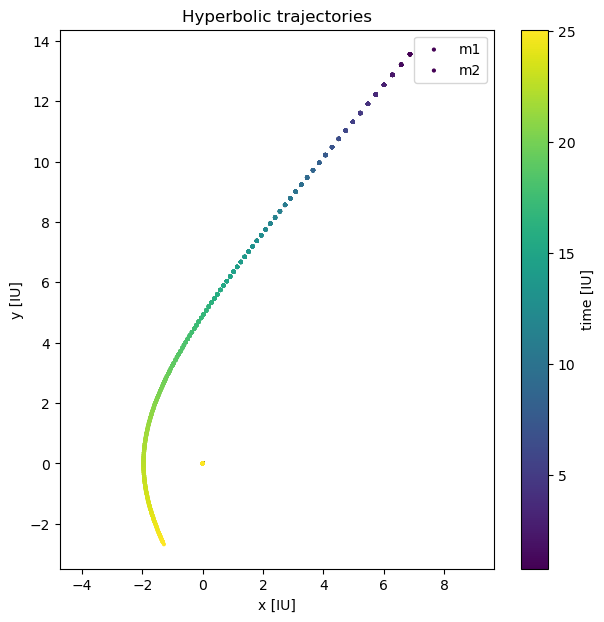

In [91]:
plt.figure(figsize=(7,7))
plt.scatter(m1_rows["x"], m1_rows["y"], c=times, s=4, label="m1")
plt.scatter(m2_rows["x"], m2_rows["y"], c=times, s=4, label="m2")
plt.xlabel("x [IU]")
plt.ylabel("y [IU]")
plt.title("Hyperbolic trajectories")
plt.axis("equal")
plt.colorbar(label="time [IU]")
plt.legend()
plt.show()

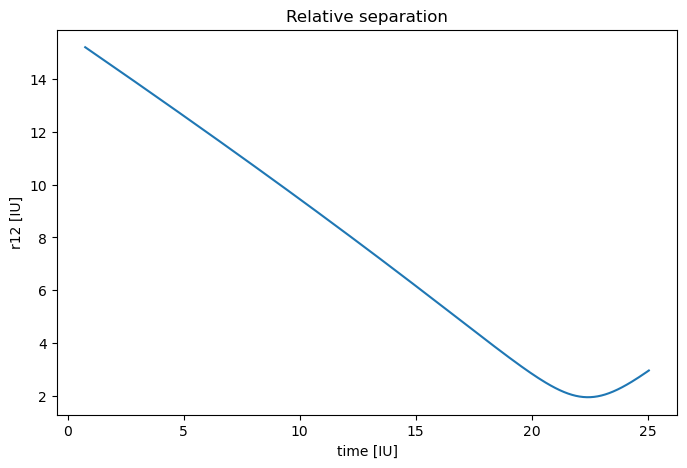

In [92]:
x1 = np.array(m1_rows["x"], dtype=float)
y1 = np.array(m1_rows["y"], dtype=float)
z1 = np.array(m1_rows["z"], dtype=float)
vx1 = np.array(m1_rows["vx"], dtype=float)
vy1 = np.array(m1_rows["vy"], dtype=float)
vz1 = np.array(m1_rows["vz"], dtype=float)

x2 = np.array(m2_rows["x"], dtype=float)
y2 = np.array(m2_rows["y"], dtype=float)
z2 = np.array(m2_rows["z"], dtype=float)
vx2 = np.array(m2_rows["vx"], dtype=float)
vy2 = np.array(m2_rows["vy"], dtype=float)
vz2 = np.array(m2_rows["vz"], dtype=float)

r_rel = np.column_stack([x2 - x1, y2 - y1, z2 - z1])
v_rel = np.column_stack([vx2 - vx1, vy2 - vy1, vz2 - vz1])

rad = np.linalg.norm(r_rel, axis=1)
vel = np.linalg.norm(v_rel, axis=1)

plt.figure(figsize=(8,5))
plt.plot(times, rad)
plt.xlabel("time [IU]")
plt.ylabel("r12 [IU]")
plt.title("Relative separation")
plt.show()

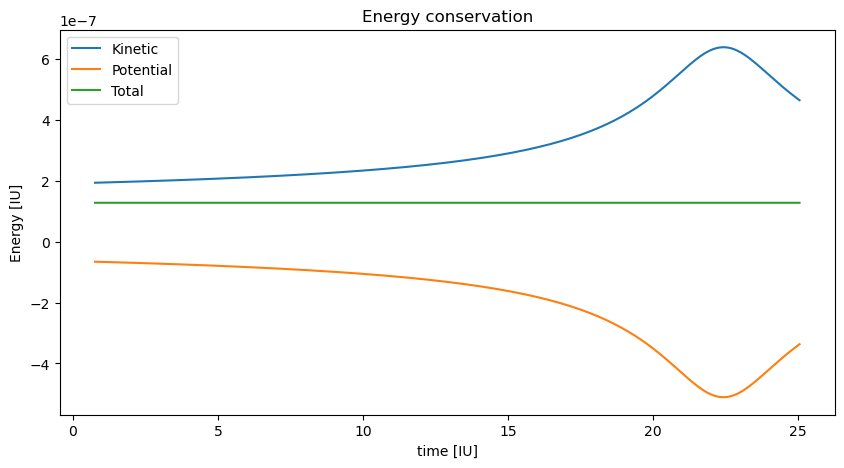

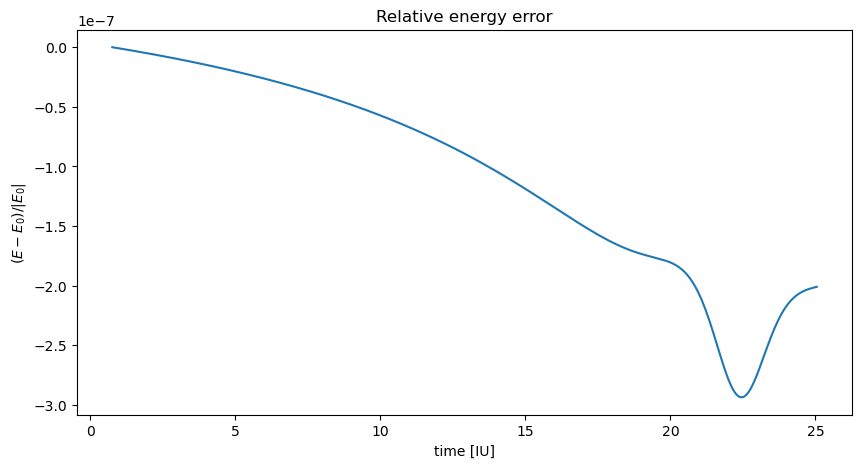

In [93]:
m1_sim = float(m1_rows.iloc[0]["m"])
m2_sim = float(m2_rows.iloc[0]["m"])

M = m1_sim + m2_sim
mu = m1_sim * m2_sim / M

EG = -M * mu / rad
EK = 0.5 * mu * vel**2
Etot = EK + EG

plt.figure(figsize=(10,5))
plt.plot(times, EK, label="Kinetic")
plt.plot(times, EG, label="Potential")
plt.plot(times, Etot, label="Total")
plt.xlabel("time [IU]")
plt.ylabel("Energy [IU]")
plt.title("Energy conservation")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(times, (Etot - Etot[0]) / abs(Etot[0]))
plt.xlabel("time [IU]")
plt.ylabel(r"$(E-E_0)/|E_0|$")
plt.title("Relative energy error")
plt.show()

Pericentro numerico = 1.9569484259610062
Tempo al pericentro = 22.42518522372785


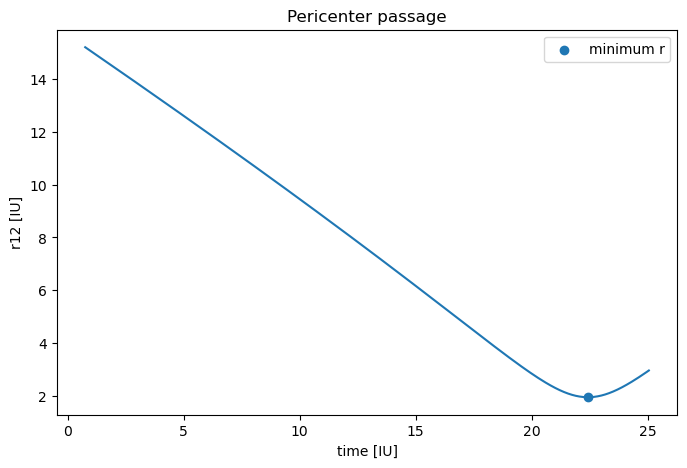

In [94]:
idx_rp = np.argmin(rad)
rp_num = rad[idx_rp]
t_rp = times[idx_rp]

print(f"Pericentro numerico = {rp_num}")
print(f"Tempo al pericentro = {t_rp}")

plt.figure(figsize=(8,5))
plt.plot(times, rad)
plt.scatter(times[idx_rp], rad[idx_rp], label="minimum r")
plt.xlabel("time [IU]")
plt.ylabel("r12 [IU]")
plt.title("Pericenter passage")
plt.legend()
plt.show()